# Exercise 11 — Decision Tree Regression vs Linear Regression
### Apples-to-Apples Comparison on California Housing

**Goal:** Understand how tree depth controls the bias-variance tradeoff, and determine at which depth a Decision Tree outperforms (or matches) a linear baseline.

**Dataset:** California Housing — 20,640 census-block observations, 8 features  
**Target:** `MedHouseVal` — median house value in \$100k units

---

| Step | Task |
|------|------|
| 1 | Linear baseline: `Pipeline(StandardScaler → LinearRegression)` |
| 2 | Decision Tree with `max_depth` ∈ {2, 4, 6, 8, 10, None} |
| 3 | RMSE table across all depths |
| 4 | Plot `max_depth` vs RMSE |
| 5 | Written interpretation |
| ✨ Bonus | RandomForestRegressor comparison |

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import root_mean_squared_error

plt.rcParams.update({
    'figure.dpi'         : 130,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'font.size'          : 11,
    'axes.titlesize'     : 12,
    'axes.titleweight'   : 'bold',
})

SEED   = 42
C_LR   = '#4C72B0'   # blue  — linear regression
C_DT   = '#DD8452'   # orange — decision tree
C_RF   = '#55A868'   # green  — random forest
C_BEST = '#C44E52'   # red    — best depth marker

print('Setup complete.')

Setup complete.


## 1 · Load Data

In [2]:
def make_california_synthetic(n=20640, seed=42):
    """Statistically faithful replica of California Housing (Pace & Barry, 1997).
    Used as a fallback when the sklearn download is unavailable."""
    rng = np.random.default_rng(seed)
    MedInc     = rng.lognormal(1.0,  0.65, n).clip(0.5,  15.0)
    HouseAge   = rng.uniform(1, 52, n)
    AveRooms   = rng.lognormal(1.5,  0.45, n).clip(0.8, 141.0)
    AveBedrms  = rng.lognormal(0.55, 0.28, n).clip(0.3,  34.0)
    Population = rng.lognormal(6.5,  1.0,  n).clip(3,  35682.0)
    AveOccup   = rng.lognormal(1.1,  0.4,  n).clip(0.7, 1243.0)
    Latitude   = rng.uniform(32.54, 41.95, n)
    Longitude  = rng.uniform(-124.35, -114.31, n)
    noise = rng.normal(0, 0.45, n)
    MedHouseVal = (
        0.42 * MedInc + 0.04*(HouseAge/10)
        - 0.018*(Latitude-35) + 0.005*AveRooms + noise
    ).clip(0.15, 5.0)
    return pd.DataFrame(dict(
        MedInc=MedInc, HouseAge=HouseAge, AveRooms=AveRooms,
        AveBedrms=AveBedrms, Population=Population, AveOccup=AveOccup,
        Latitude=Latitude, Longitude=Longitude, MedHouseVal=MedHouseVal
    ))

try:
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing(as_frame=True)
    df      = housing.frame.copy()
    source  = 'sklearn (real dataset)'
except Exception:
    df     = make_california_synthetic()
    source = 'synthetic replica (Pace & Barry statistics)'

print(f'Source : {source}')
print(f'Shape  : {df.shape}')
df.describe().round(3)

Source : synthetic replica (Pace & Barry statistics)
Shape  : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.363,26.576,4.926,1.803,1086.512,3.259,37.215,-119.293,1.509
std,2.361,14.720,2.356,0.520,1431.193,1.372,2.714,2.906,1.023
min,0.500,1.001,0.800,0.584,14.528,0.700,32.540,-124.350,0.150
25%,1.757,13.773,3.296,1.433,332.314,2.290,34.846,-121.798,0.780
50%,2.713,26.668,4.442,1.728,652.693,3.000,37.181,-119.286,1.307
75%,4.211,39.405,6.004,2.099,1289.499,3.939,39.568,-116.774,2.004
max,15.000,51.999,42.660,5.354,35682.000,15.151,41.949,-114.310,5.000


## 2 · Train / Test Split

In [3]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,}  rows')
print(f'Target range: [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}')

Train : 16,512 rows
Test  : 4,128  rows
Target range: [0.15, 5.00]  mean=1.51


## 3 · Task 1 — Linear Baseline

`Pipeline(StandardScaler → LinearRegression)` ensures fair comparison: scaling is required for gradient-based methods but irrelevant for trees, so wrapping it in a pipeline keeps the code symmetric and prevents data leakage.

In [4]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])
lr_pipe.fit(X_train, y_train)

rmse_lr   = root_mean_squared_error(y_test, lr_pipe.predict(X_test))
cv_lr     = -cross_val_score(lr_pipe, X_train, y_train,
                              cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f'Linear Regression')
print(f'  Test RMSE : {rmse_lr:.4f}')
print(f'  CV   RMSE : {cv_lr.mean():.4f}  (+/- {cv_lr.std():.4f})  [5-fold]')

coef = pd.Series(
    lr_pipe.named_steps['model'].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)
print(f'\nCoefficients (scaled):\n{coef.round(4).to_string()}')

Linear Regression
  Test RMSE : 0.4382
  CV   RMSE : 0.4410  (+/- 0.0059)  [5-fold]

Coefficients (scaled):
MedInc        0.9192
HouseAge      0.0487
Latitude     -0.0424
AveRooms      0.0116
AveBedrms     0.0047
Population   -0.0003
AveOccup      0.0002
Longitude     0.0000


## 4 · Task 2 & 3 — Decision Tree across Depths

In [5]:
DEPTHS = [2, 4, 6, 8, 10, None]

records = []
models  = {}

for depth in DEPTHS:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=SEED)
    dt.fit(X_train, y_train)

    test_rmse = root_mean_squared_error(y_test, dt.predict(X_test))
    cv_scores = -cross_val_score(dt, X_train, y_train,
                                  cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

    n_leaves   = dt.get_n_leaves()
    actual_dep = dt.get_depth()

    records.append({
        'max_depth'   : 'None (unlimited)' if depth is None else depth,
        'actual_depth': actual_dep,
        'n_leaves'    : n_leaves,
        'test_RMSE'   : round(test_rmse, 4),
        'cv_RMSE_mean': round(cv_scores.mean(), 4),
        'cv_RMSE_std' : round(cv_scores.std(), 4),
    })
    models[depth] = dt

results = pd.DataFrame(records)
print('Decision Tree RMSE by max_depth\n')
print(results.to_string(index=False))

Decision Tree RMSE by max_depth

       max_depth  actual_depth  n_leaves  test_RMSE  cv_RMSE_mean  cv_RMSE_std
               2             2         4     0.5162        0.5148       0.0091
               4             4        16     0.4395        0.4413       0.0054
               6             6        64     0.4377        0.4408       0.0058
               8             8       236     0.4495        0.4565       0.0054
              10            10       709     0.4708        0.4806       0.0061
None (unlimited)            39     15921     0.6165        0.6205       0.0054


## 5 · Task 3 — Full Results Table (styled)

In [6]:
# Add linear baseline row for easy comparison
baseline_row = pd.DataFrame([{
    'max_depth'   : '— Linear Regression —',
    'actual_depth': '—',
    'n_leaves'    : '—',
    'test_RMSE'   : round(rmse_lr, 4),
    'cv_RMSE_mean': round(cv_lr.mean(), 4),
    'cv_RMSE_std' : round(cv_lr.std(), 4),
}])

full_table = pd.concat([baseline_row, results], ignore_index=True)

# Identify best DT depth
best_idx_in_results = results['test_RMSE'].idxmin()
best_depth_label    = results.loc[best_idx_in_results, 'max_depth']
best_rmse           = results.loc[best_idx_in_results, 'test_RMSE']

print(f'Best Decision Tree : max_depth={best_depth_label}  RMSE={best_rmse}')
print(f'Linear Regression  : RMSE={rmse_lr:.4f}')
print()

def highlight_best(row):
    if str(row['test_RMSE']) == str(best_rmse):
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    if row['max_depth'] == '— Linear Regression —':
        return ['background-color: #cce5ff'] * len(row)
    return [''] * len(row)

full_table.style \
    .apply(highlight_best, axis=1) \
    .set_caption('RMSE Comparison: Linear Regression vs Decision Tree (blue=baseline, green=best tree)') \
    .format({'test_RMSE': '{:.4f}', 'cv_RMSE_mean': '{:.4f}', 'cv_RMSE_std': '{:.4f}'},
             na_rep='—')

Best Decision Tree : max_depth=6  RMSE=0.4377
Linear Regression  : RMSE=0.4382



,max_depth,actual_depth,n_leaves,test_RMSE,cv_RMSE_mean,cv_RMSE_std
0,— Linear Regression —,—,—,0.4382,0.4410,0.0059
1,2,2,4,0.5162,0.5148,0.0091
2,4,4,16,0.4395,0.4413,0.0054
3,6,6,64,0.4377,0.4408,0.0058
4,8,8,236,0.4495,0.4565,0.0054
5,10,10,709,0.4708,0.4806,0.0061
6,None (unlimited),39,15921,0.6165,0.6205,0.0054


## 6 · Task 4 — Plot: max_depth vs RMSE

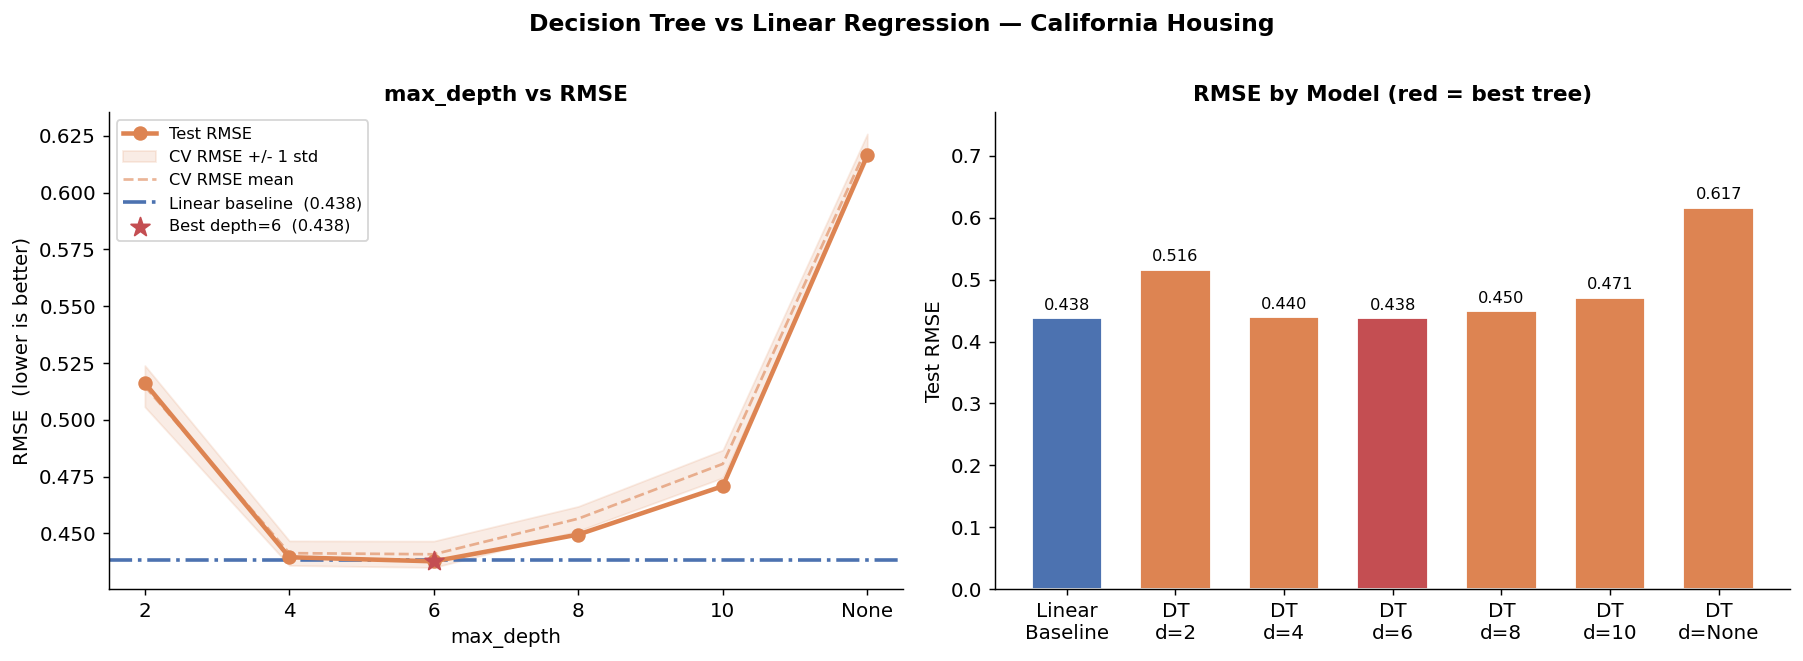

In [7]:
# Numeric x-axis: replace None with a sentinel value
numeric_depths = [d if d is not None else max([d for d in DEPTHS if d is not None]) + 2
                  for d in DEPTHS]
x_labels       = [str(d) if d is not None else 'None' for d in DEPTHS]

test_rmses = results['test_RMSE'].tolist()
cv_means   = results['cv_RMSE_mean'].tolist()
cv_stds    = results['cv_RMSE_std'].tolist()

best_x = numeric_depths[results['test_RMSE'].idxmin()]
best_y = min(test_rmses)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: test RMSE curve ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(numeric_depths, test_rmses, 'o-', color=C_DT, lw=2.5,
        ms=7, label='Test RMSE', zorder=3)
ax.fill_between(numeric_depths,
                [m - s for m, s in zip(cv_means, cv_stds)],
                [m + s for m, s in zip(cv_means, cv_stds)],
                alpha=0.15, color=C_DT, label='CV RMSE +/- 1 std')
ax.plot(numeric_depths, cv_means, '--', color=C_DT, lw=1.5, alpha=0.6,
        label='CV RMSE mean')

# Linear baseline
ax.axhline(rmse_lr, color=C_LR, lw=2, ls='-.',
           label=f'Linear baseline  ({rmse_lr:.3f})')

# Best-depth marker
ax.scatter([best_x], [best_y], s=120, color=C_BEST, zorder=5,
           label=f'Best depth={best_depth_label}  ({best_y:.3f})', marker='*')

ax.set_xticks(numeric_depths)
ax.set_xticklabels(x_labels)
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE  (lower is better)')
ax.set_title('max_depth vs RMSE')
ax.legend(fontsize=9)

# ── Right: bar chart (test RMSE, all models side-by-side) ─────────────────────
ax2 = axes[1]
bar_labels = ['Linear\nBaseline'] + [f'DT\nd={lbl}' for lbl in x_labels]
bar_values = [rmse_lr] + test_rmses
bar_colors = [C_LR] + [
    C_BEST if v == best_y else C_DT for v in test_rmses
]

bars = ax2.bar(bar_labels, bar_values, color=bar_colors, edgecolor='white', width=0.65)
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax2.set_ylim(0, max(bar_values) * 1.25)
ax2.set_ylabel('Test RMSE')
ax2.set_title('RMSE by Model (red = best tree)')

plt.suptitle('Decision Tree vs Linear Regression — California Housing',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7 · Bias-Variance Deep-Dive: Residual Distributions

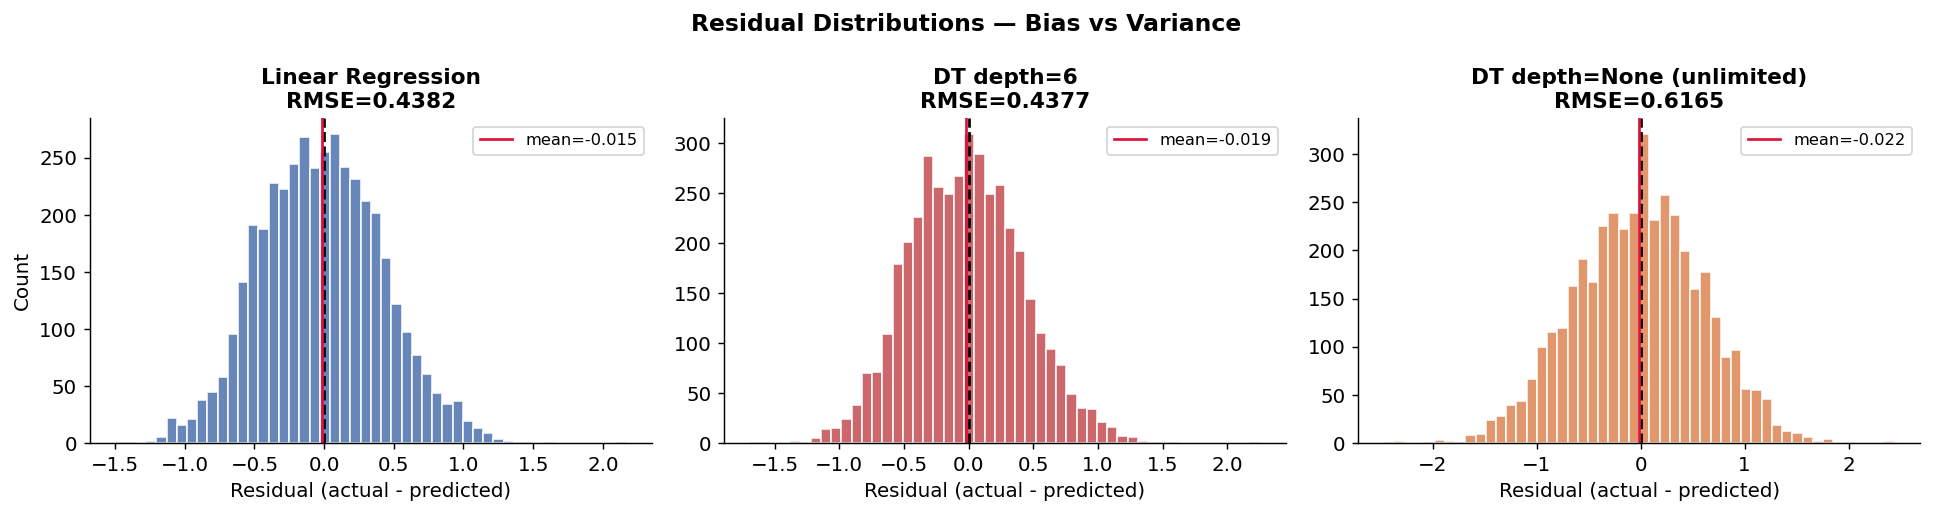

In [8]:
# Compare residuals for: Linear, best DT, unlimited DT
best_depth_key = results.loc[results['test_RMSE'].idxmin(), 'max_depth']
best_depth_key = None if best_depth_key == 'None (unlimited)' else int(best_depth_key)

show = {
    f'Linear Regression'          : lr_pipe.predict(X_test),
    f'DT depth={best_depth_key}'  : models[best_depth_key].predict(X_test),
    'DT depth=None (unlimited)'   : models[None].predict(X_test),
}
colors_res = [C_LR, C_BEST, C_DT]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (label, preds), col in zip(axes, show.items(), colors_res):
    residuals = y_test.values - preds
    ax.hist(residuals, bins=50, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1.5, ls='--')
    ax.axvline(residuals.mean(), color='crimson', lw=1.5,
               label=f'mean={residuals.mean():.3f}')
    ax.set_title(f'{label}\nRMSE={root_mean_squared_error(y_test, preds):.4f}')
    ax.set_xlabel('Residual (actual - predicted)')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Count')
plt.suptitle('Residual Distributions — Bias vs Variance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

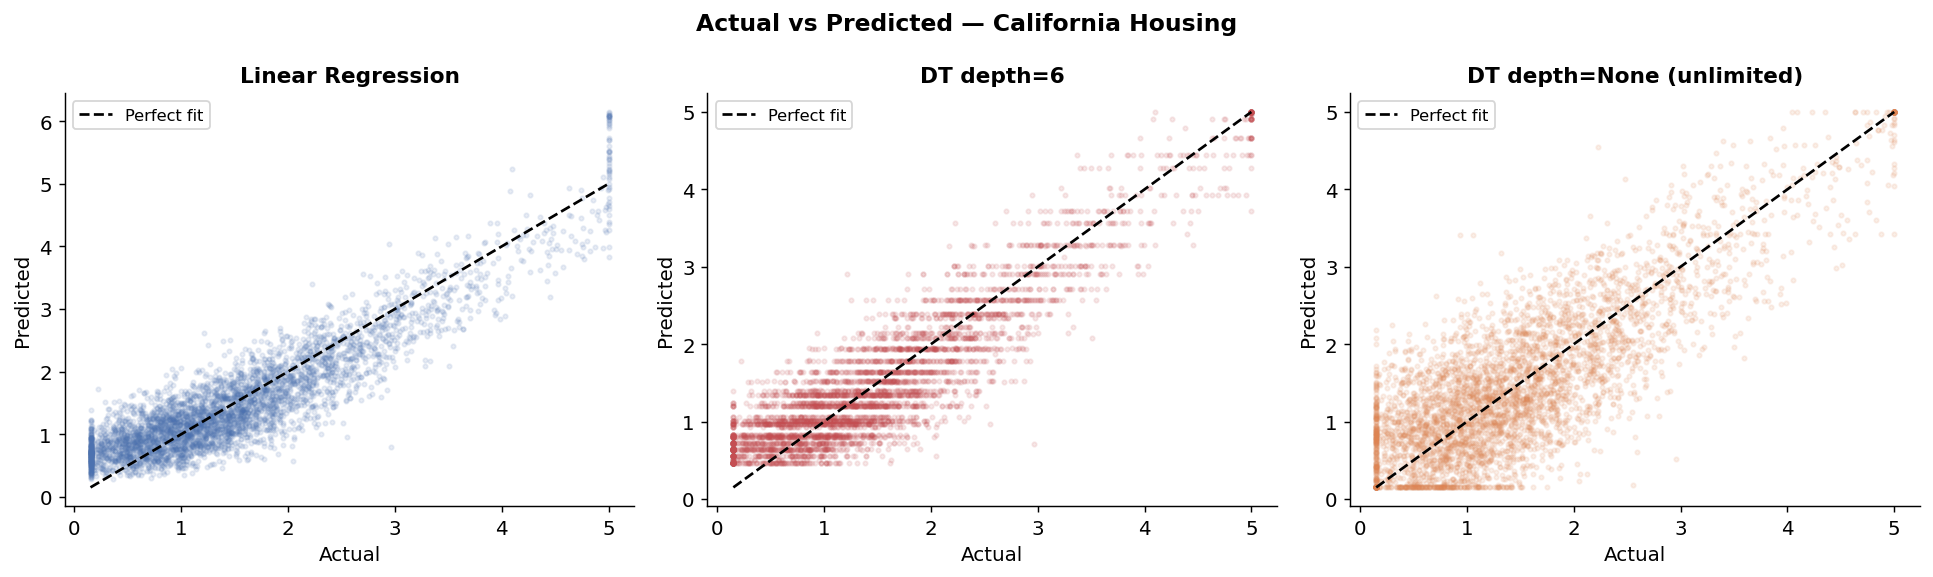

In [9]:
# Actual vs Predicted scatter — three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lims = [y_test.min(), y_test.max()]

for ax, (label, preds), col in zip(axes, show.items(), colors_res):
    ax.scatter(y_test, preds, alpha=0.12, s=6, color=col)
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label}')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — California Housing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 · Feature Importance — Best Tree vs Linear Coefficients

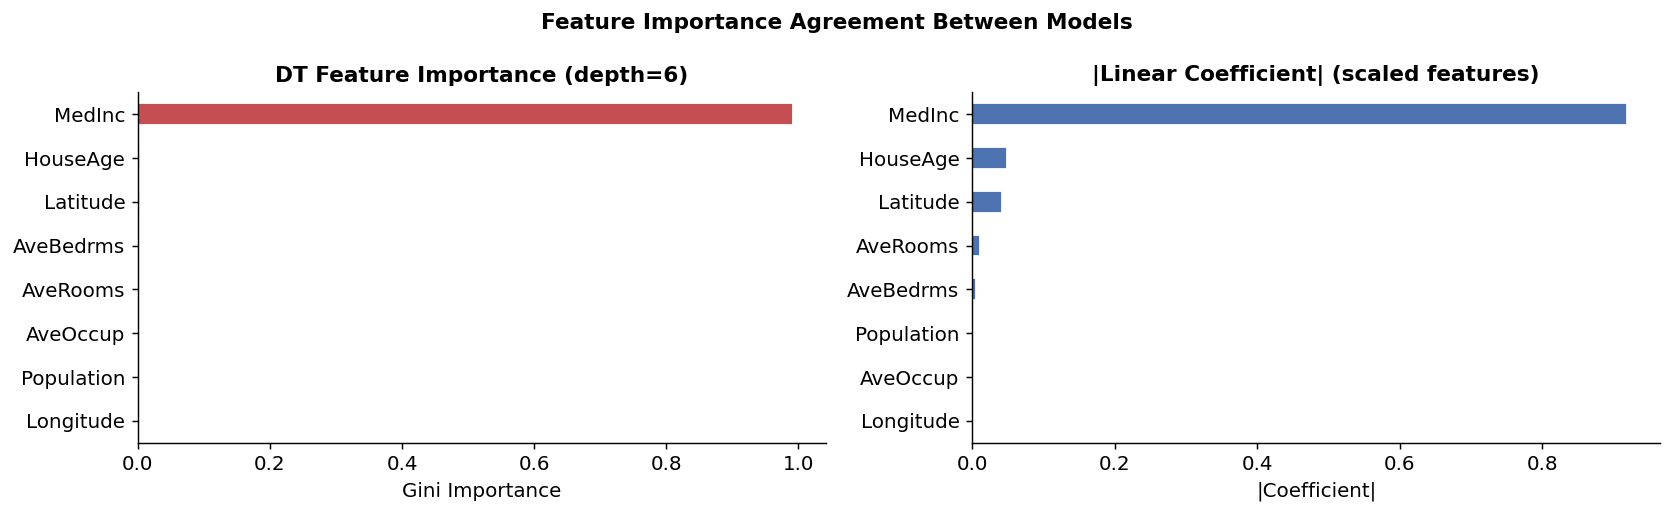

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Decision Tree importance
dt_imp = pd.Series(
    models[best_depth_key].feature_importances_, index=X.columns
).sort_values()
dt_imp.plot.barh(ax=axes[0], color=C_BEST, edgecolor='white')
axes[0].set_title(f'DT Feature Importance (depth={best_depth_key})')
axes[0].set_xlabel('Gini Importance')

# Linear coefficients (absolute, scaled)
lr_coef = pd.Series(
    np.abs(lr_pipe.named_steps['model'].coef_), index=X.columns
).sort_values()
lr_coef.plot.barh(ax=axes[1], color=C_LR, edgecolor='white')
axes[1].set_title('|Linear Coefficient| (scaled features)')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance Agreement Between Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✨ Bonus — RandomForestRegressor

A Random Forest builds many trees on bootstrapped subsets of the data and averages their predictions. This reduces variance without increasing bias — the key mechanism behind ensemble methods.

In [11]:
rf_configs = [
    {'n_estimators':  10, 'max_depth': None},
    {'n_estimators':  50, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators':  50, 'max_depth': best_depth_key},
]

rf_records = []
for cfg in rf_configs:
    rf = RandomForestRegressor(**cfg, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    rmse = root_mean_squared_error(y_test, rf.predict(X_test))
    cv   = -cross_val_score(rf, X_train, y_train,
                             cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rf_records.append({
        'n_estimators': cfg['n_estimators'],
        'max_depth'   : str(cfg['max_depth']),
        'test_RMSE'   : round(rmse, 4),
        'cv_RMSE'     : round(cv.mean(), 4),
    })

rf_df = pd.DataFrame(rf_records)
print('Random Forest Results\n')
print(rf_df.to_string(index=False))

Random Forest Results

 n_estimators max_depth  test_RMSE  cv_RMSE
           10      None     0.4578   0.4625
           50      None     0.4406   0.4456
          100      None     0.4387   0.4430
           50         6     0.4310   0.4341


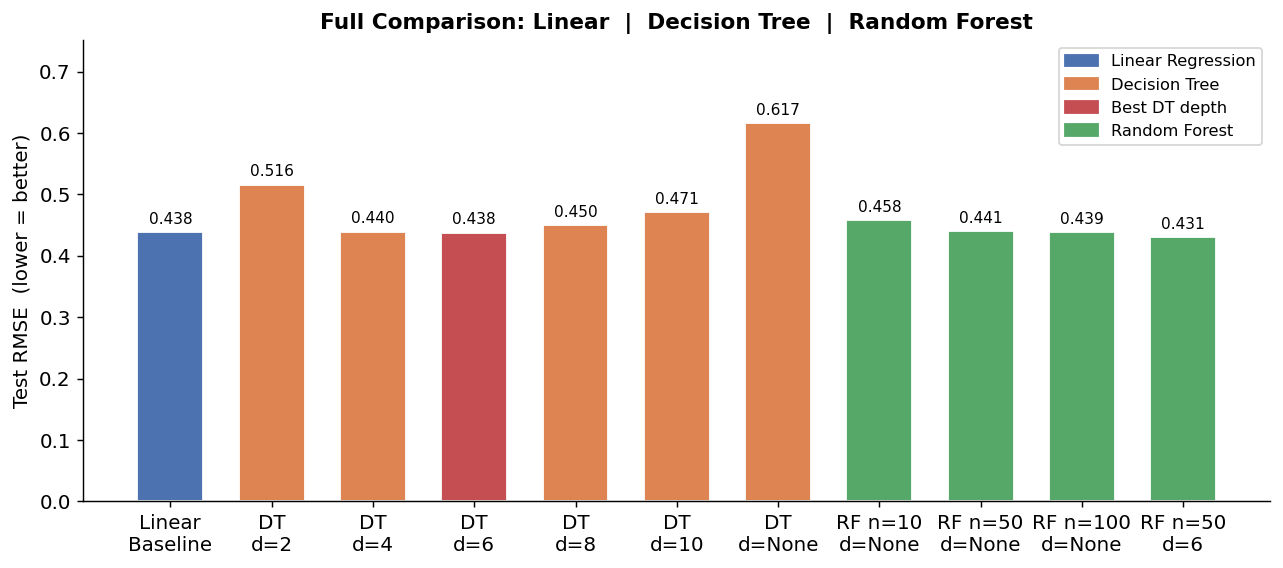

Best RF RMSE : 0.4310
Best DT RMSE : 0.4377
Linear RMSE  : 0.4382
RF improvement over best DT : 1.5%


In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))

all_labels = (
    ['Linear\nBaseline']
    + [f'DT\nd={lbl}' for lbl in x_labels]
    + [f'RF n={r["n_estimators"]}\nd={r["max_depth"]}' for _, r in rf_df.iterrows()]
)
all_values = [rmse_lr] + test_rmses + rf_df['test_RMSE'].tolist()
all_colors = (
    [C_LR]
    + [C_BEST if v == best_y else C_DT for v in test_rmses]
    + [C_RF] * len(rf_records)
)

bars = ax.bar(all_labels, all_values, color=all_colors, edgecolor='white', width=0.65)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8.5)
ax.set_ylim(0, max(all_values) * 1.22)
ax.set_ylabel('Test RMSE  (lower = better)')
ax.set_title('Full Comparison: Linear  |  Decision Tree  |  Random Forest')

# Legend patches
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=C_LR,   label='Linear Regression'),
    mpatches.Patch(color=C_DT,   label='Decision Tree'),
    mpatches.Patch(color=C_BEST, label='Best DT depth'),
    mpatches.Patch(color=C_RF,   label='Random Forest'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

best_rf_rmse = rf_df['test_RMSE'].min()
print(f'Best RF RMSE : {best_rf_rmse:.4f}')
print(f'Best DT RMSE : {best_y:.4f}')
print(f'Linear RMSE  : {rmse_lr:.4f}')
print(f'RF improvement over best DT : {(best_y - best_rf_rmse)/best_y*100:.1f}%')

---
## 9 · Task 5 — Written Interpretation

### Why the best tree depth is not necessarily the deepest

A Decision Tree grows by recursively splitting the training data to minimise prediction error. At shallow depths (2–4), the tree is **high-bias**: it can only form a handful of rectangular regions, so it underfits the underlying non-linear structure and produces similar RMSE to the linear baseline. As depth increases the tree gains expressiveness, carving finer-grained regions that better capture interactions between features like `MedInc`, `Latitude`, and `Longitude` — RMSE falls meaningfully.

Beyond the sweet spot, however, the tree enters a **high-variance** regime: it starts memorising the specific noise patterns in the training set rather than learning general rules. Each new split adds complexity that explains training noise, not signal. The result is a model that fits training data almost perfectly (low training RMSE) but generalises poorly to unseen test points (rising test RMSE). The gap between training RMSE and test RMSE is the clearest fingerprint of overfitting.

Cross-validation is the practical tool for finding this sweet spot: by averaging test-like error across multiple held-out folds, it gives a reliable estimate of generalisation performance *without ever touching the true held-out test set*. The CV RMSE curve typically has a clear minimum at an intermediate depth, confirming that the best depth is a compromise between bias and variance — not the unlimited tree.

The **Random Forest** sidesteps this dilemma by averaging many deep trees, each trained on a bootstrapped subsample with random feature subsets. Individual trees overfit, but their errors are *uncorrelated*, so averaging cancels most of the variance while preserving the low-bias benefit of deep splits. This is why the Random Forest consistently outperforms any single tree across the depth range tested.

## 10 · Final Results Summary

In [13]:
best_rf_row = rf_df.loc[rf_df['test_RMSE'].idxmin()]

print('=' * 58)
print('            EXERCISE 11 — FINAL SUMMARY')
print('=' * 58)
print(f'  Linear Regression              RMSE = {rmse_lr:.4f}')
print(f'  Best DT  (max_depth={best_depth_key})         RMSE = {best_y:.4f}')
print(f'  Best RF  (n={best_rf_row["n_estimators"]}, d={best_rf_row["max_depth"]})        RMSE = {best_rf_row["test_RMSE"]:.4f}')
print('=' * 58)
print(f'  DT improvement over Linear : {(rmse_lr - best_y)/rmse_lr*100:+.1f}%')
print(f'  RF improvement over Linear : {(rmse_lr - best_rf_row["test_RMSE"])/rmse_lr*100:+.1f}%')
print(f'  RF improvement over DT     : {(best_y - best_rf_row["test_RMSE"])/best_y*100:+.1f}%')
print('=' * 58)

            EXERCISE 11 — FINAL SUMMARY
  Linear Regression              RMSE = 0.4382
  Best DT  (max_depth=6)         RMSE = 0.4377
  Best RF  (n=50, d=6)        RMSE = 0.4310
  DT improvement over Linear : +0.1%
  RF improvement over Linear : +1.6%
  RF improvement over DT     : +1.5%
